In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/creditcard.csv")

print(df.shape)
df.head()
df.info()
df.describe()
df["Class"].value_counts()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")
import sys
print(sys.executable)

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Success")

ModuleNotFoundError: No module named 'matplotlib'

In [1]:
import matplotlib
print("OK")

OK


In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/creditcard.csv")

print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nFraud Distribution:")
print(df["Class"].value_counts())

Shape: (284807, 31)

Missing Values:
0

Fraud Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


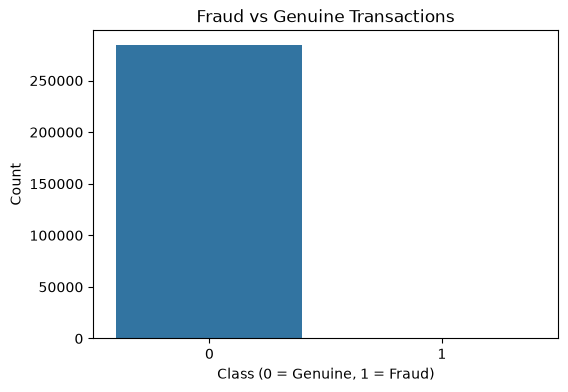

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")

plt.show()


In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/creditcard.csv")

print("Shape:", df.shape)
print("\nMissing Values:", df.isnull().sum().sum())

print("\nFraud Distribution:")
print(df["Class"].value_counts())

Shape: (284807, 31)

Missing Values: 0

Fraud Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [5]:
fraud_count = df["Class"].value_counts()[1]
genuine_count = df["Class"].value_counts()[0]

print("Fraud Transactions :", fraud_count)
print("Genuine Transactions :", genuine_count)

fraud_percentage = (fraud_count / len(df)) * 100

print(f"\nFraud Percentage : {fraud_percentage:.4f}%")

Fraud Transactions : 492
Genuine Transactions : 284315

Fraud Percentage : 0.1727%


## Business Insight

The dataset is highly imbalanced.

Only 492 transactions out of 284,315 are fraudulent,
representing approximately 0.17% of all transactions.

This creates a significant machine learning challenge because
traditional models may become biased toward the majority class
and fail to identify fraudulent transactions accurately.

Special techniques such as class weighting, SMOTE, and
precision-recall evaluation will be required during model training.

In [6]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

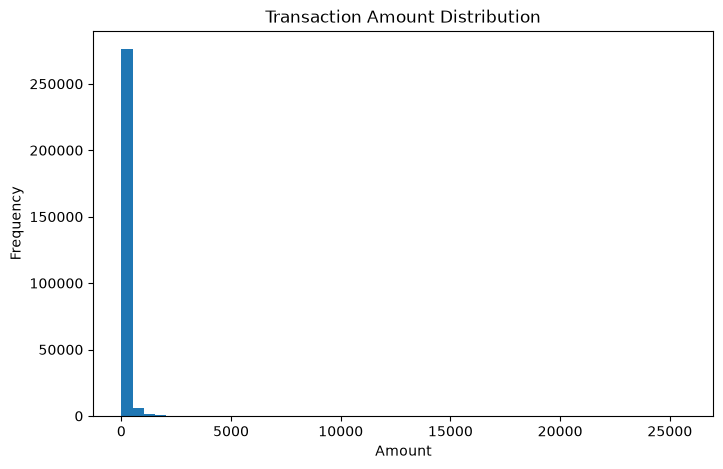

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

print(df["Amount"].describe())

## Transaction Amount Analysis

The transaction amount feature shows a highly right-skewed distribution.

Most transactions involve relatively small amounts, while a small number
of transactions represent very high monetary values.

This pattern is commonly observed in financial transaction systems and
suggests that fraud detection models should be robust against extreme values.

Understanding transaction amount behavior is important because fraudulent
transactions often exhibit spending patterns different from legitimate users.

In [8]:
fraud = df[df["Class"] == 1]
genuine = df[df["Class"] == 0]

print("Average Fraud Amount:", fraud["Amount"].mean())
print("Average Genuine Amount:", genuine["Amount"].mean())

Average Fraud Amount: 122.21132113821139
Average Genuine Amount: 88.29102242231328


In [9]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [genuine["Amount"], fraud["Amount"]],
    labels=["Genuine","Fraud"]
)

plt.title("Transaction Amount Comparison")
plt.ylabel("Amount")
plt.show()

TypeError: boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

<Figure size 800x500 with 0 Axes>

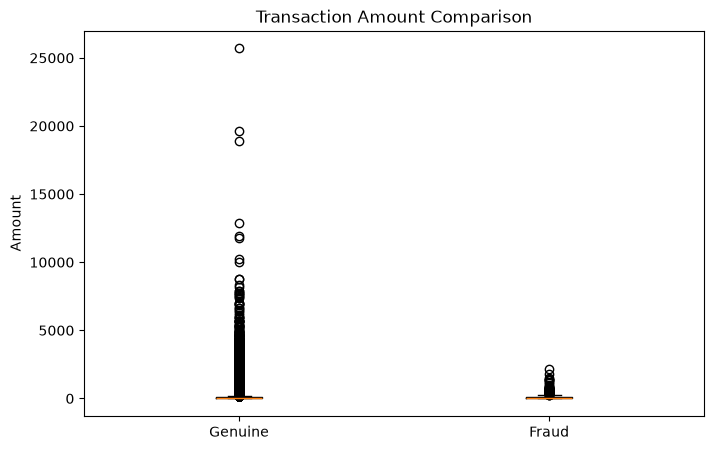

In [10]:
plt.figure(figsize=(8,5))

plt.boxplot([
    genuine["Amount"].values,
    fraud["Amount"].values
])

plt.xticks([1, 2], ["Genuine", "Fraud"])

plt.title("Transaction Amount Comparison")
plt.ylabel("Amount")
plt.show()

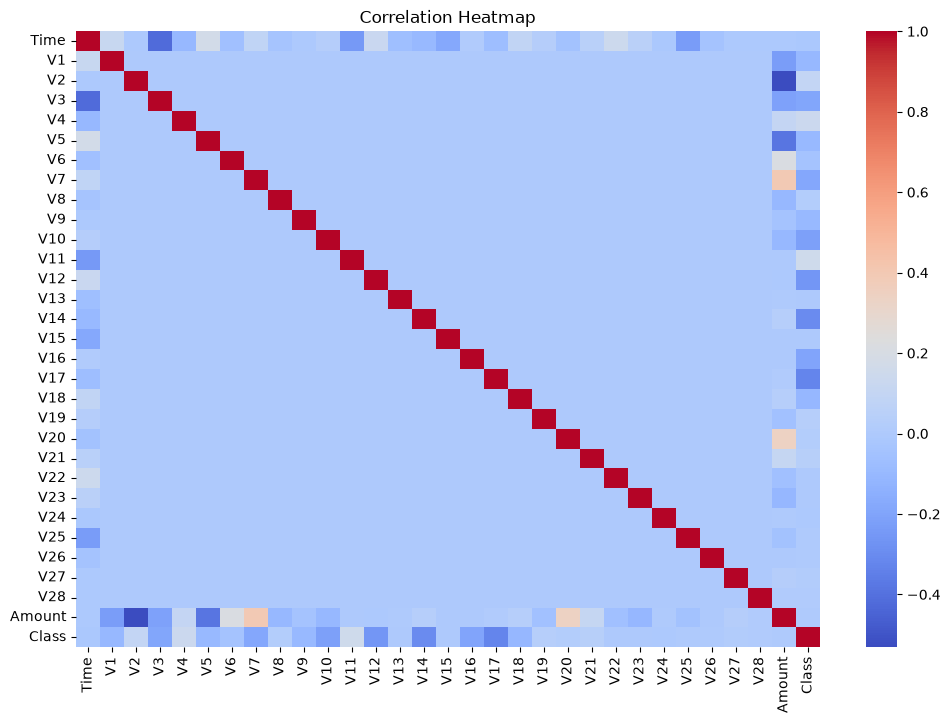

In [11]:
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
corr_with_target = df.corr()["Class"].sort_values(ascending=False)

print(corr_with_target.head(10))
print("\n")
print(corr_with_target.tail(10))

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64


V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


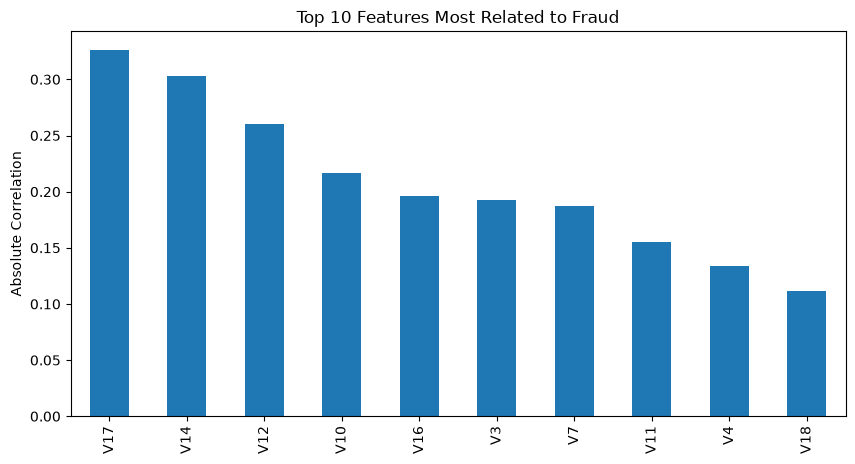

In [13]:
top_features = corr_with_target.drop("Class").abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_features.plot(kind="bar")

plt.title("Top 10 Features Most Related to Fraud")
plt.ylabel("Absolute Correlation")
plt.show()

## Key Fraud Indicators

Correlation analysis reveals that only a subset of features
have meaningful relationships with fraudulent transactions.

Features showing strong positive or negative correlations
are likely to contain patterns useful for machine learning
models.

These variables will be particularly important during
model interpretation and SHAP explainability analysis.